<a href="https://colab.research.google.com/github/Kccev802/kccev/blob/main/Lab6_MorphologyProcessing_khadijah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Morphological Operations (AI342)
**Student Name:** [خديجة يوسف الحربي] | **Student ID:** [4456770]
---
### Instructions:
* Do **NOT** add or delete any cells.
* Task 1 is provided as a reference. Complete the missing parts in other tasks.
* Pay attention to the variable names and the requested Structuring Elements.

## Task 1: Basic Operations & Area Analysis
In this section, we apply **Erosion**, **Dialation**, **Opening** and **Closing** and analyze the resulting object areas. Also, we compare a custom **Square Structuring Element** and a **Disk Structuring Element**.
.

Original Area: 1600 pixels
Erosion Area: 1296 pixels
Dilation Area: 1936 pixels
Opening Area: 1580 pixels
Closing Area: 1600 pixels


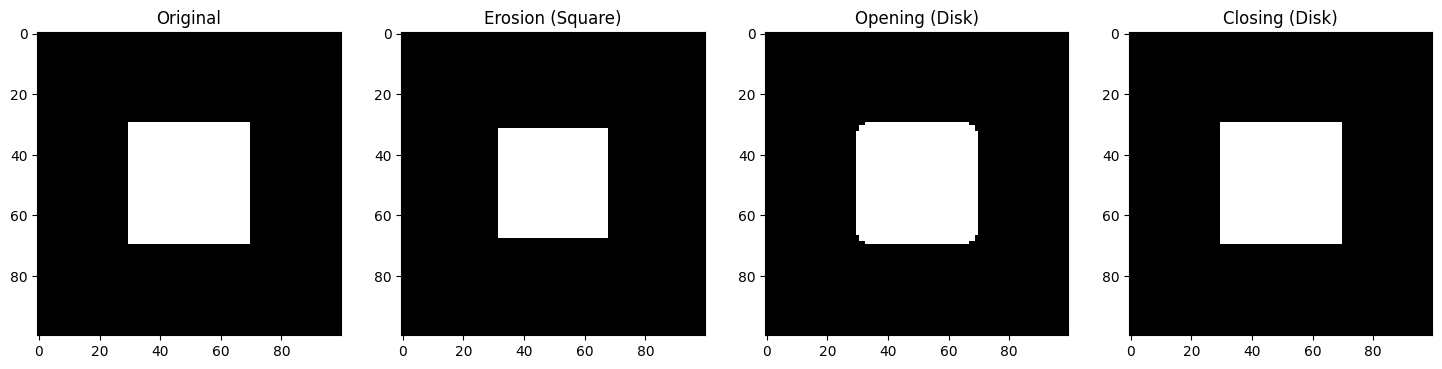

In [2]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion
from skimage import morphology, data

# Setup Image
img = np.zeros((100, 100), dtype=bool)
img[30:70, 30:70] = True

# 1. Custom Square Structuring Element
se_square = np.ones((5,5), bool)
# 2. Disk Structuring Element
se_disk = morphology.disk(3)

# Applying Operations
ero_res = binary_erosion(img, structure=se_square)
dil_res = binary_dilation(img, structure=se_square)
open_res = morphology.binary_opening(img, se_disk)
close_res = morphology.binary_closing(img, se_disk)

# Area Comparison
print(f"Original Area: {np.sum(img)} pixels")
print(f"Erosion Area: {np.sum(ero_res)} pixels")
print(f"Dilation Area: {np.sum(dil_res)} pixels")
print(f"Opening Area: {np.sum(open_res)} pixels")
print(f"Closing Area: {np.sum(close_res)} pixels")

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(ero_res, cmap='gray'); axes[1].set_title("Erosion (Square)")
axes[2].imshow(open_res, cmap='gray'); axes[2].set_title("Opening (Disk)")
axes[3].imshow(close_res, cmap='gray'); axes[3].set_title("Closing (Disk)")
plt.show()

---
**Q1: Based on the printed area values, why did the area decrease in Erosion/Opening and increase in Dilation/Closing?**

*Answer:*
Erosion removes pixels from the object's boundaries, making the object smaller and decreasing the area. Dilation adds pixels to the boundaries, making it larger and increasing the area. Opening (erosion followed by dilation) tends to remove small noise or outward protrusions, causing a net decrease in area. Closing (dilation followed by erosion) fills small holes and gaps, causing a net increase

## Task 2: Boundary Extraction
**Formula:** $Boundary = A \oplus (A \ominus B)$
**Note:** Use **Logical XOR** (`^` or `np.logical_xor`) instead of set difference.

**Requirement:** Apply boundary extraction using two different Disk sizes: `disk(1)` and `disk(3)`.

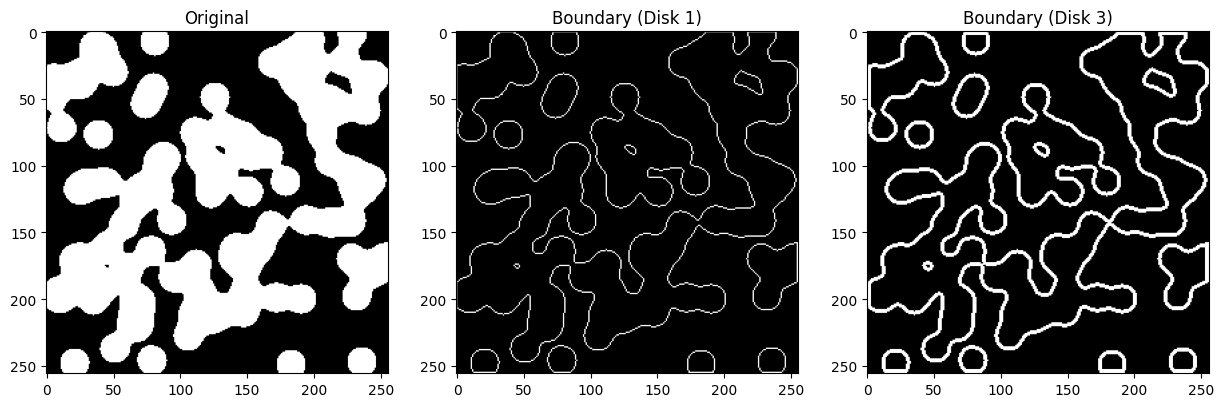

In [3]:
# TODO: Implement Boundary Extraction
# Use 'binary_img' (Blobs) for this task
rng = np.random.default_rng(seed=42)
binary_img = data.binary_blobs(length=256, blob_size_fraction=0.1, rng=rng)

# 1. Extract boundary using morphology.disk(1)
eroded_1 = binary_erosion(binary_img, structure=morphology.disk(1))
boundary_1 = np.logical_xor(binary_img, eroded_1)
# 2. Extract boundary using morphology.disk(3)
eroded_3 = binary_erosion(binary_img, structure=morphology.disk(3))
boundary_3 = np.logical_xor(binary_img, eroded_3)
# 3. Display the results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(boundary_1, cmap='gray')
axes[1].set_title("Boundary (Disk 1)")
axes[2].imshow(boundary_3, cmap='gray')
axes[2].set_title("Boundary (Disk 3)")
plt.show()


---
**Q2: Compare the boundaries extracted using disk(1) and disk(3). What is the effect of SE size on the boundary?**

Answer:The boundary extracted with disk(3) is much thicker than the one with disk(1). A larger structuring element erodes more pixels from the inside of the object, so when we use the Logical XOR operation to find the difference with the original image, a wider and thicker border is left behind.

# Task 3: Controlled Thinning & Thickening
**Mathematical Note:**

Since the library does not provide a direct thick function, we use the Duality Principle:
Thickening an image $A$ is equivalent to thinning the complement of $A$ ($A^c$), then complementing the result:$$\text{Thickening}(A) = \text{Thinning}(A^c)^c$$

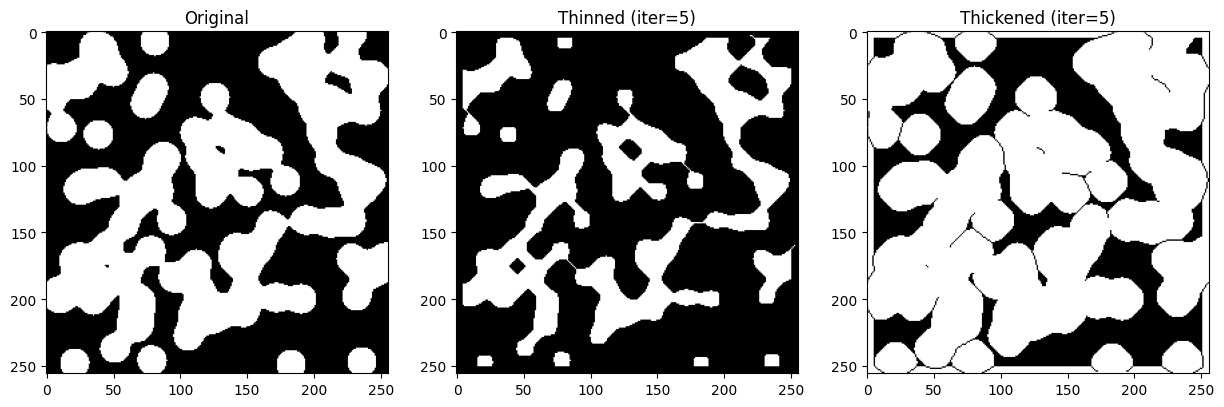

In [4]:
# --- STUDENT CODE HERE ---
# 1. Apply Thinning with max_num_iter = 5
# 2. Apply Thickening with max_num_iter = 5
# Note: Use the duality principle for thickening: ~thin(~image)
# 3. Display the Original, Thinned, and Thickened images side-by-side.

# [Your Code Starts]
# 1. Apply Thinning with max_num_iter = 5
thinned_img = morphology.thin(binary_img, max_num_iter=5)
# 2. Apply Thickening with max_num_iter = 5
# Note: Use the duality principle for thickening: ~thin(~image)
thickened_img = ~morphology.thin(~binary_img, max_num_iter=5)
# 3. Display the Original, Thinned, and Thickened images side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(thinned_img, cmap='gray')
axes[1].set_title("Thinned (iter=5)")
axes[2].imshow(thickened_img, cmap='gray')
axes[2].set_title("Thickened (iter=5)")
plt.show()

# [Your Code Ends]

---
**Q3: How does Thinning differ from Erosion in terms of shape preservation?**

Answer:Thinning systematically peels away the outer layers of an object but preserves its basic topological shape and connectivity (eventually reducing it to a skeleton). Erosion, on the other hand, shrinks the object uniformly from all sides and can completely destroy or disconnect the shape if applied too many times.

## Task 4: Hit-or-Miss End-Point Detection
**Objective:** Detect all ridge endings using a rotating Structuring Element.
**Formula:** $A \circledast B = (A \ominus B_1) \cap (A^c \ominus B_2)$

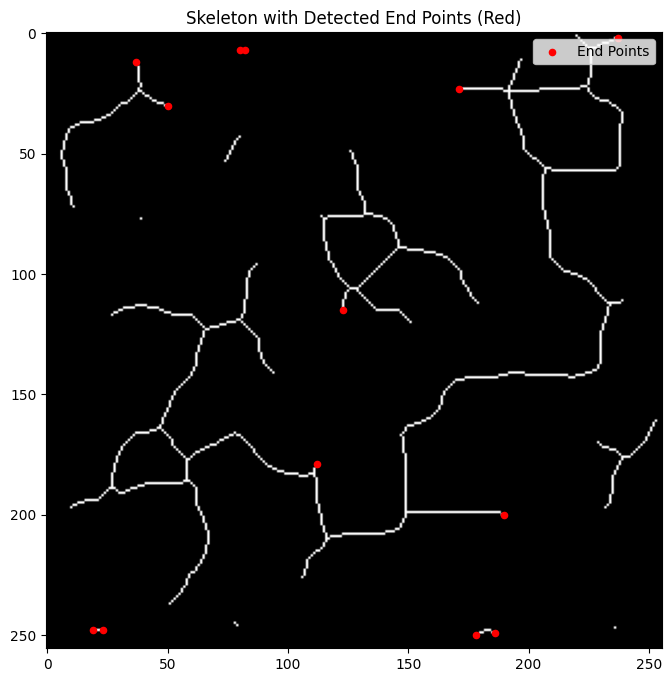

In [5]:
from scipy.ndimage import binary_hit_or_miss
from skimage.morphology import skeletonize

# Prepare Skeleton
skeleton = skeletonize(binary_img)

# Define the Base Structuring Element (End-point pattern)
se_base = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 1, 0]], dtype=bool)

# --- CODE STRUCTURE (Complete the missing parts) ---
all_end_points = np.zeros_like(skeleton, dtype=bool)

# Loop to detect endings in all 4 directions
for i in range(4):
    # Rotate the 'se_base' by 90 degrees 'i' times
    # use np.rot90(m, k) where m is SE
    # and k: The number of times the array is rotated by 90 degrees.
    se_rotated = np.rot90(se_base, i)

    # Apply binary_hit_or_miss
    detected = binary_hit_or_miss(skeleton, se_rotated)

    # Combine results
    all_end_points |= detected

# Visualization (Final Result Overlay)
plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='gray')
y, x = np.where(all_end_points)
plt.scatter(x, y, color='red', s=20, label='End Points')
plt.title("Skeleton with Detected End Points (Red)")
plt.legend()
plt.show()

---
**Q4: In the Hit-or-Miss logic, what does the '1' and '0' in our Structuring Element represent?**

Answer:In the Hit-or-Miss transform, the '1' represents the foreground pixels (the actual skeleton) that must be present for an exact match. The '0' represents the background pixels that must also exactly match to ensure there are no extra connected pixels in those specific spots, allowing us to successfully isolate the end-point.